# Smallest stiffness eigenvalue versus strain — SIM 4000 and 4010 families

This notebook makes separate plots for SIM_4000–SIM_4009 and SIM_4010–SIM_4019. It loads the same `DATA_PICK_*_EIGV.pkl` files used by Video_3101. Curves are labeled by the internal pressure used to create each simulation.

For this family, Step-1 applies a 5 mm displacement over a 20 mm specimen dimension. The nominal compressive strain is therefore defined as `0.25 * t`, where `t` is the normalized Step-1 time stored in `DATA_PICK_*_EIGV.pkl`.

In [ ]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path('../I001_Results')
PRESSURES = (0.0,) + tuple(0.04 * np.sqrt(2.0) ** i for i in range(9))
FAMILIES = {
    'SIM 4000 family — hexagonal packing': range(4000, 4010),
    'SIM 4010 family — random packing': range(4010, 4020),
}
SPECIMEN_DIMENSION = 20.0  # mm
IMPOSED_DISPLACEMENT = 5.0  # mm
MAX_STRAIN = IMPOSED_DISPLACEMENT / SPECIMEN_DIMENSION

print(f'Result directory: {RESULTS_DIR.resolve()}')
print(f'Nominal maximum compressive strain: {MAX_STRAIN:.1%}')


Result directory: /Disk_F/FOAM_V03/I001_Results
Nominal maximum compressive strain: 25.0%


In [ ]:
curves = {}
missing = []
invalid = []

for family_name, sim_ids in FAMILIES.items():
    curves[family_name] = {}
    for sim_id in sim_ids:
        path = RESULTS_DIR / f'DATA_PICK_{sim_id}_EIGV.pkl'
        if not path.exists():
            missing.append(sim_id)
            continue

        with path.open('rb') as handle:
            data = pickle.load(handle)

        try:
            time = np.asarray(data['t'], dtype=float)
            eigenvalues = np.asarray(data['eigenvalues'], dtype=float)
            if eigenvalues.ndim != 2 or eigenvalues.shape[1] == 0:
                raise ValueError('eigenvalues does not contain mode columns')
            if len(time) != len(eigenvalues):
                raise ValueError('time and eigenvalue lengths differ')
        except (KeyError, TypeError, ValueError) as error:
            invalid.append((sim_id, str(error)))
            continue

        # The first stored mode is the smallest eigenvalue at each snapshot.
        strain = MAX_STRAIN * time
        pressure = PRESSURES[sim_id % 10]
        curves[family_name][sim_id] = {
            'strain': strain,
            'lambda_min': eigenvalues[:, 0],
            'pressure': pressure,
        }

print('Loaded curves:')
for family_name, family_curves in curves.items():
    print(f'  {family_name}: {sorted(family_curves)}')
if missing:
    print(f'Missing eigenvalue files for: {missing}')
if invalid:
    print(f'Invalid eigenvalue files: {invalid}')


Loaded curves:
  SIM 4000 family — hexagonal packing: [4001, 4002, 4003, 4004, 4005, 4006, 4007, 4008, 4009]
  SIM 4010 family — random packing: [4010, 4011, 4012, 4013, 4014, 4015, 4016, 4017, 4018]
Missing eigenvalue files for: [4000, 4019]


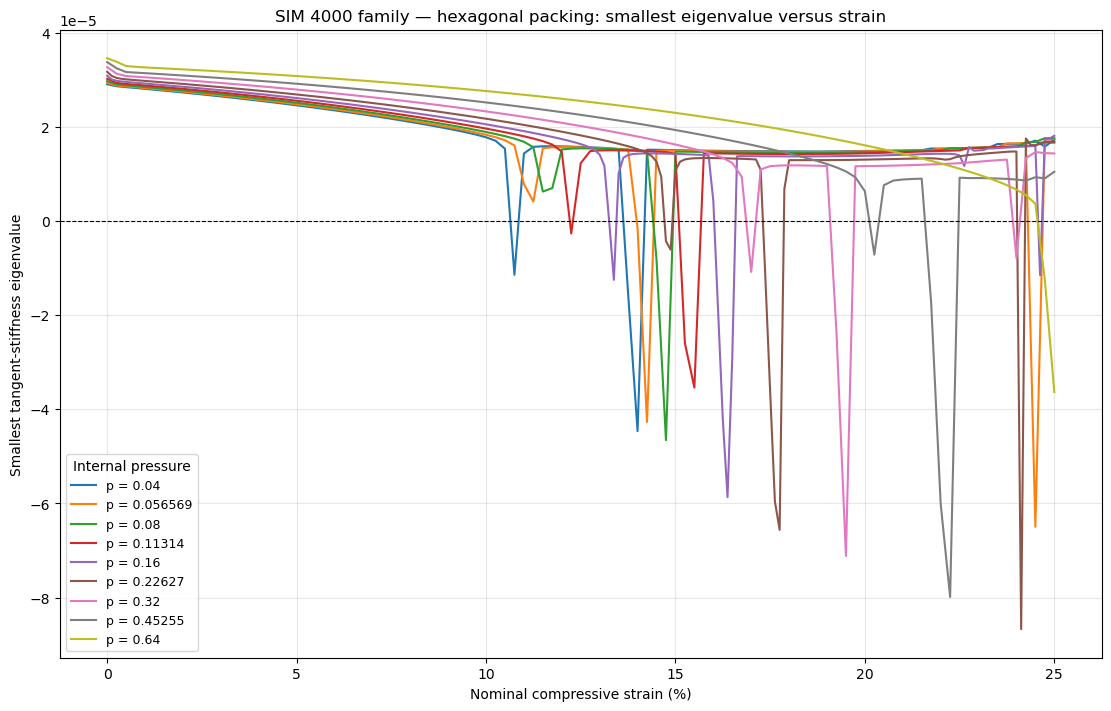

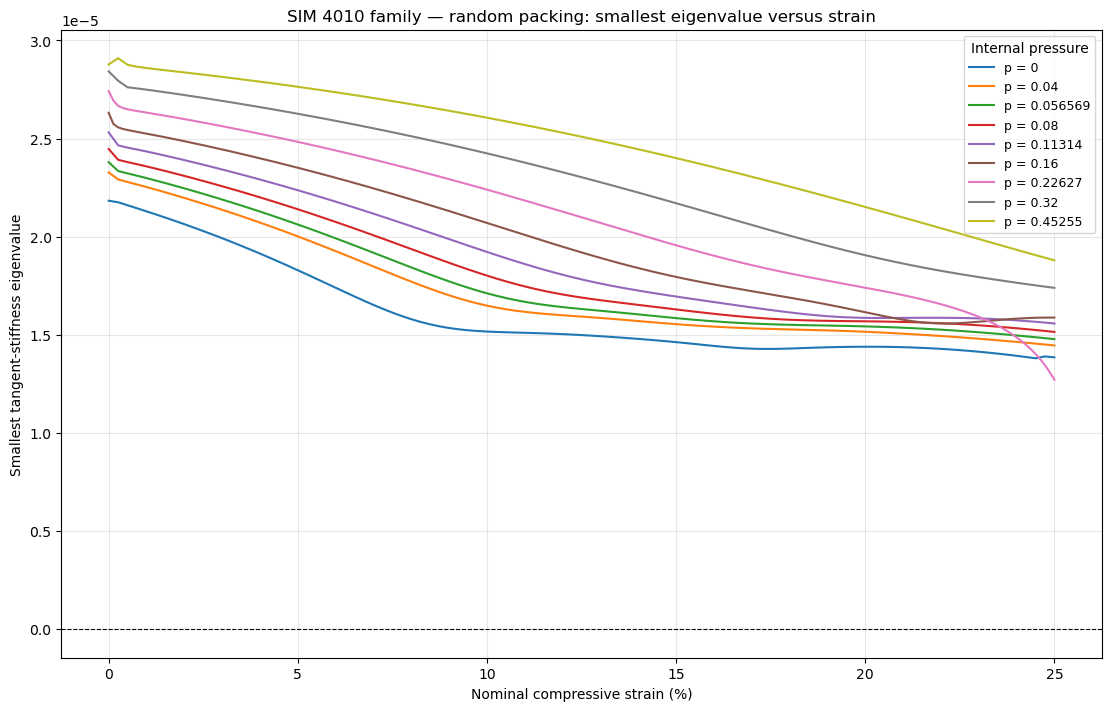

In [ ]:
figures = {}
for family_name, family_curves in curves.items():
    fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
    for sim_id, data in sorted(family_curves.items()):
        ax.plot(
            100 * data['strain'],
            data['lambda_min'],
            linewidth=1.5,
            label=f"p = {data['pressure']:.5g}",
        )
    ax.axhline(0.0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Nominal compressive strain (%)')
    ax.set_ylabel('Smallest tangent-stiffness eigenvalue')
    ax.set_title(f'{family_name}: smallest eigenvalue versus strain')
    ax.grid(True, alpha=0.3)
    if family_curves:
        ax.legend(title='Internal pressure', fontsize=9, loc='best')
    figures[family_name] = fig
    plt.show()


In [ ]:
# Optional: save both figures next to the notebook.
output_paths = {
    'SIM 4000 family — hexagonal packing': Path('SIM_4000s_smallest_eigenvalue_vs_strain.png'),
    'SIM 4010 family — random packing': Path('SIM_4010s_smallest_eigenvalue_vs_strain.png'),
}
for family_name, output_path in output_paths.items():
    if family_name in figures:
        figures[family_name].savefig(output_path, dpi=200, bbox_inches='tight')
        print(f'Saved: {output_path.resolve()}')


Saved: /Disk_F/FOAM_V03/Z001_Results_Analizer/SIM_4000s_smallest_eigenvalue_vs_strain.png
Saved: /Disk_F/FOAM_V03/Z001_Results_Analizer/SIM_4010s_smallest_eigenvalue_vs_strain.png
